The goal for integrating LLM with OntoSearcher's RDF mappings is to 
- give the LLM more context for more accruate classifcation and prediction so that it can infer from previous knoweldge graphs about the types of nanomaterials that might be present as well as other factors

- help with the generation of SPARQL queries 

- help with the generation of new ontologies and RDF mappings for unkown data


# Look into neo4j for convert knoweldge graphs into a database and then using that for graph rag 

# RDF visualization tool?

- 2 parts to widget, rdf visualization and interactive thing, and llm interface

In [ ]:
# first we want to take our generated rdfs(for now, only have niosh, cpsc, and nanoKnowbase data, will add OSHA data soon)


In [7]:
import rdflib
from rdflib import Graph, URIRef
from collections import defaultdict

# Load your RDF file
g = Graph()
g.parse("./mappings/niosh_rdf_tutV2c.ttl", format="turtle")

# Structures to capture schema information
classes = set()          # Types of resources
predicates = set()       # Properties used
predicate_domains = defaultdict(set)  # What types of resources use each property
predicate_ranges = defaultdict(set)   # What types of values each property has
class_properties = defaultdict(set)   # What properties are used with each class

# For each subject in the graph
for s in set(g.subjects()):
    # Get all types for this subject
    types = list(g.objects(s, rdflib.RDF.type))
    
    # If this subject has a type, add it to our classes
    for t in types:
        classes.add(t)
        
        # For each predicate and object used with this subject
        for p, o in g.predicate_objects(s):
            predicates.add(p)
            predicate_domains[p].add(t)
            class_properties[t].add(p)
            
            # Check if object is a literal or a resource
            if isinstance(o, rdflib.Literal):
                # Add datatype if available
                if o.datatype:
                    predicate_ranges[p].add(f"xsd:{g.compute_qname(o.datatype)[2]}")
                else:
                    predicate_ranges[p].add("Literal")
            elif isinstance(o, URIRef):
                # If object is a resource, check if it has a type
                obj_types = list(g.objects(o, rdflib.RDF.type))
                if obj_types:
                    for ot in obj_types:
                        predicate_ranges[p].add(ot)
                else:
                    predicate_ranges[p].add("Resource")

# Print the extracted schema
print("=== CLASSES ===")
for c in classes:
    print(f"Class: {g.qname(c)}")
    print("  Properties:")
    for p in class_properties[c]:
        p_ranges = ", ".join(g.qname(r) if isinstance(r, URIRef) else r for r in predicate_ranges[p])
        print(f"    - {g.qname(p)} → {p_ranges}")
    print()

print("=== PREDICATES ===")
for p in predicates:
    p_domains = ", ".join(g.qname(d) for d in predicate_domains[p])
    p_ranges = ", ".join(g.qname(r) if isinstance(r, URIRef) else r for r in predicate_ranges[p])
    print(f"Property: {g.qname(p)}")
    print(f"  Domain: {p_domains}")
    print(f"  Range: {p_ranges}")
    print()

=== CLASSES ===
Class: ncit:C156601
  Properties:
    - obo:OBI_0000679 → xsd:double
    - rdf:type → Resource
    - sio:CHEMINF_000009 → ncit:C53321
    - rdfs:label → Literal, xsd:double
    - sio:SIO_000391 → Literal, xsd:double
    - sio:SIO_000221 → Literal, xsd:double

Class: npo:NPO_1407
  Properties:
    - obo:RO_0000053 → sio:CHEMINF_000515, enm:ENM_0000084, obo:CMO_0000096, ncit:C158424, obo:CHMO_0002354, ncit:C41145, npo:NPO_1812, sio:SIO_000049, ncit:C25334, ncit:C25330, ncit:C68568, ncit:C25285, enm:ENM_9000001, ncit:C62354, ncit:C25488, ns1:EFO_0000487
    - obo:SCDO_0000482 → blkv:SubjectOfInvestigation
    - rdf:type → Resource
    - sio:SIO_000216 → ncit:C156601
    - rdfs:comment → Literal, xsd:double

Class: ncit:C25488
  Properties:
    - sio:SIO_000300 → Literal, xsd:double
    - sio:SIO_000221 → Literal, xsd:double
    - rdf:type → Resource
    - sio:CHEMINF_000009 → ncit:C53321

Class: ns1:EFO_0000487
  Properties:
    - obo:RO_0000053 → sio:CHEMINF_000515, enm:E

Loading RDF from ./mappings/cpsc_database.ttl...
Parsed 29596 triples
Analyzing schema structure...
Found 1 classes and 9 properties
RDF Schema Summary:
Total triples: 29596
Classes: 1
Properties: 9

Top 5 Classes (by instance count):
  npo:NPO_199: 2785 instances

Top Properties (by usage):
  dcterms:description: 5792 uses
  ochv:C0034030: 3075 uses
  obo:MESH_D012306: 3075 uses
  rdf:type: 2785 uses
  ncit:C93401: 2785 uses
Building network representation...
Created network with 1 nodes and 0 edges


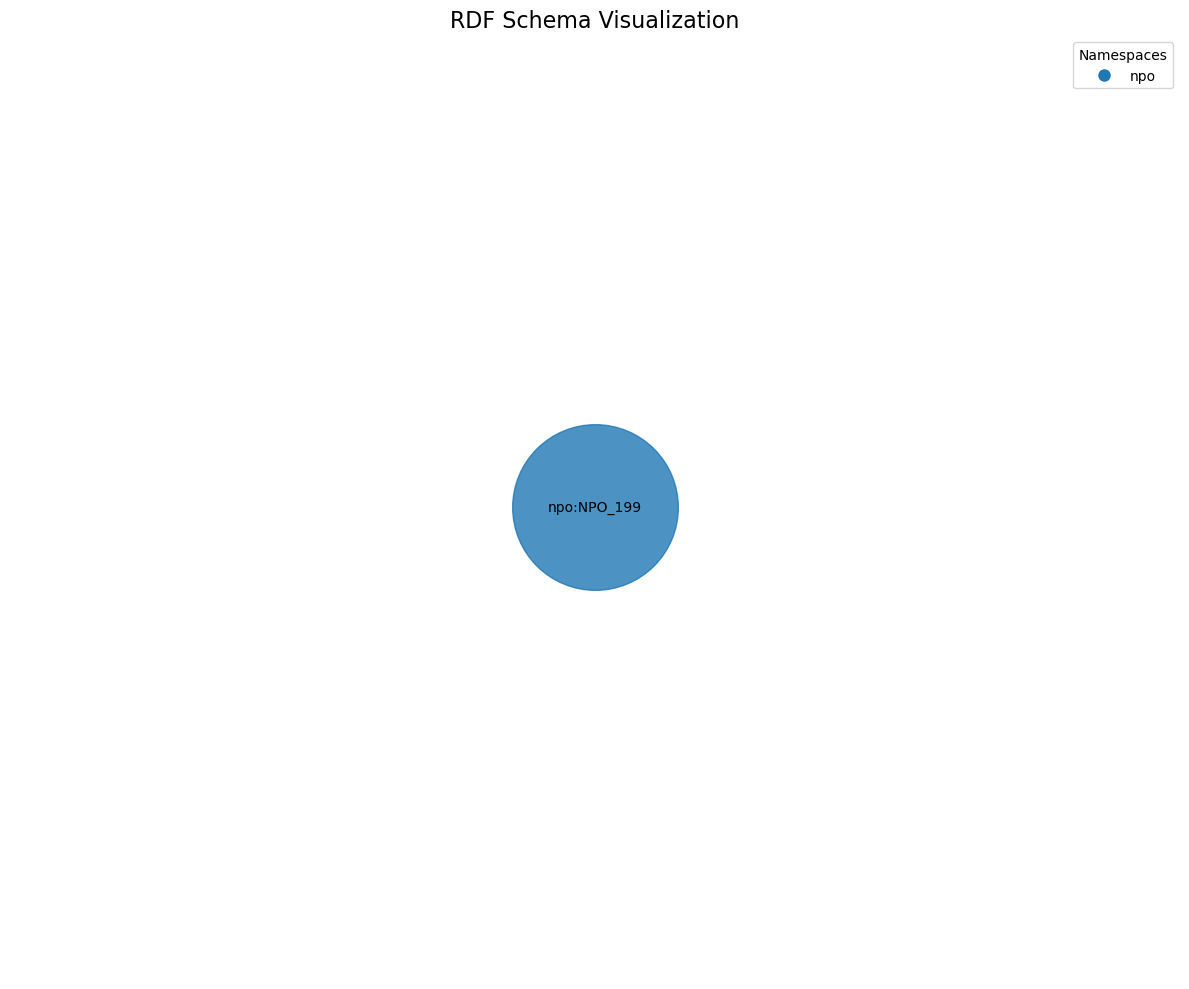

ValueError: unsupported format character ';' (0x3b) at index 389

In [5]:
schema_triples

[]

In [4]:
# Find cross-namespace links
cross_namespace_links = []
for s, p, o in g:
    s_namespace = str(s).split('#')[0] if '#' in str(s) else str(s).rsplit('/', 1)[0] + '/'
    o_namespace = str(o).split('#')[0] if '#' in str(o) else str(o).rsplit('/', 1)[0] + '/' if isinstance(o, rdflib.URIRef) else None
    
    if o_namespace and s_namespace != o_namespace:
        cross_namespace_links.append((s, p, o))

# Print a sample of cross-namespace links
for s, p, o in cross_namespace_links[:10]:  # Show first 10 examples
    print(f"{g.qname(s)} {g.qname(p)} {g.qname(o) if isinstance(o, rdflib.URIRef) else o}")

assay:211 obo:RO_0002242 ns1:exposure
assay:217 ncit:C64542 ns2:organsystem
assay:253 rdf:type obo:OBI_0000070
ns3:exposure obo:RO_0000053 ns4:dose
ns5:duration rdf:type ncit:C25330
exp:70 rdf:type npo:NPO_1407
ns6:timepoint rdf:type ncit:C68568
assay:328 obo:RO_0002242 ns7:exposure
ns8:exposure obo:RO_0000053 ns9:timepoint
ns10:subjectofinvestigation sno:363808001 ns11:bodyweight


In [1]:
pip install neo4j

  Obtaining dependency information for neo4j from https://files.pythonhosted.org/packages/6a/57/94225fe5e9dabdc0ff60c88cbfcedf11277f4b34e7ab1373d3e62dbdd207/neo4j-5.28.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.3/312.3 kB 620.8 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [7]:
import rdflib
from rdflib.term import BNode
from neo4j import GraphDatabase
import os
from typing import Dict, List, Set, Tuple
import re

class ComplexRDFLoader:
    def __init__(self, uri: str, username: str, password: str):
        """Initialize connection to Neo4j"""
        self.driver = GraphDatabase.driver(uri, auth=(username, password))
        self.bnode_map = {}  # Track blank nodes and their Neo4j IDs
    
    def close(self):
        """Close the Neo4j connection"""
        self.driver.close()
    
    def create_schema_indexes(self):
        """Create schema-aware constraints and indexes"""
        with self.driver.session() as session:
            # Create constraint on resource URIs
            session.run("""
            CREATE CONSTRAINT IF NOT EXISTS FOR (n:Resource) REQUIRE n.uri IS UNIQUE
            """)
            
            # Create entity-specific indexes based on RDF types
            session.run("""
            CREATE INDEX IF NOT EXISTS FOR (n:Product) ON (n.uri)
            """)
            
            session.run("""
            CREATE INDEX IF NOT EXISTS FOR (n:Assay) ON (n.uri)
            """)
            
            session.run("""
            CREATE INDEX IF NOT EXISTS FOR (n:Material) ON (n.uri)
            """)
            
            # Create indexes for common search properties
            # These will vary based on your ontology
            property_indexes = [
                "NPO_1808",  # nanomaterial type
                "label",
                "C93401",    # product type
                "description"
            ]
            
            for prop in property_indexes:
                session.run(f"""
                CREATE INDEX IF NOT EXISTS FOR (n:Resource) ON (n.{prop})
                """)
    
    def extract_ontology_terms(self, g):
        """
        Extract ontology term information to enrich the graph
        """
        ontology_info = {}
        
        # Find all class definitions
        class_query = """
        SELECT ?class ?label ?comment
        WHERE {
            { ?class a owl:Class } UNION { ?class a rdfs:Class }
            OPTIONAL { ?class rdfs:label ?label }
            OPTIONAL { ?class rdfs:comment ?comment }
        }
        """
        
        try:
            for row in g.query(class_query):
                class_uri = str(row)
                ontology_info[class_uri] = {
                    "type": "Class",
                    "label": str(row.label) if row.label else None,
                    "comment": str(row.comment) if row.comment else None
                }
        except Exception as e:
            print(f"Error querying ontology classes: {e}")
        
        # Find all property definitions
        property_query = """
        SELECT ?prop ?label ?comment ?domain ?range
        WHERE {
            { ?prop a owl:ObjectProperty } UNION 
            { ?prop a owl:DatatypeProperty } UNION
            { ?prop a rdf:Property }
            OPTIONAL { ?prop rdfs:label ?label }
            OPTIONAL { ?prop rdfs:comment ?comment }
            OPTIONAL { ?prop rdfs:domain ?domain }
            OPTIONAL { ?prop rdfs:range ?range }
        }
        """
        
        try:
            for row in g.query(property_query):
                prop_uri = str(row.prop)
                ontology_info[prop_uri] = {
                    "type": "Property",
                    "label": str(row.label) if row.label else None,
                    "comment": str(row.comment) if row.comment else None,
                    "domain": str(row.domain) if row.domain else None,
                    "range": str(row.range) if row.range else None
                }
        except Exception as e:
            print(f"Error querying ontology properties: {e}")
        
        return ontology_info
    
    def analyze_graph_structure(self, g):
        """
        Analyze the RDF graph to identify entity types and key relationships
        """
        # Find all RDF type declarations
        type_counts = {}
        
        for s, p, o in g.triples((None, rdflib.RDF.type, None)):
            obj_type = str(o)
            if obj_type not in type_counts:
                type_counts[obj_type] = 0
            type_counts[obj_type] += 1
        
        # Identify key entity types based on frequency
        entity_types = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
        
        print("RDF Entity Types:")
        for entity_type, count in entity_types[:10]:  # Show top 10
            print(f"  {entity_type}: {count} instances")
        
        # Analyze predicate usage
        predicate_counts = {}
        
        for s, p, o in g:
            pred = str(p)
            if pred not in predicate_counts:
                predicate_counts[pred] = 0
            predicate_counts[pred] += 1
        
        # Identify key predicates
        key_predicates = sorted(predicate_counts.items(), key=lambda x: x[1], reverse=True)
        
        print("\nTop Predicates:")
        for pred, count in key_predicates[:10]:  # Show top 10
            print(f"  {pred}: {count} uses")
        
        # Identify blank node patterns
        bnode_patterns = {}
        
        for s, p, o in g:
            if isinstance(s, BNode):
                if str(p) not in bnode_patterns:
                    bnode_patterns[str(p)] = {"as_subject": 0, "as_object": 0}
                bnode_patterns[str(p)]["as_subject"] += 1
            
            if isinstance(o, BNode):
                if str(p) not in bnode_patterns:
                    bnode_patterns[str(p)] = {"as_subject": 0, "as_object": 0}
                bnode_patterns[str(p)]["as_object"] += 1
        
        print("\nBlank Node Patterns:")
        for pred, counts in bnode_patterns.items():
            print(f"  {pred}: subject={counts['as_subject']}, object={counts['as_object']}")
        
        return {
            "entity_types": entity_types,
            "key_predicates": key_predicates,
            "bnode_patterns": bnode_patterns
        }
    
    def clean_property_name(self, uri: str) -> str:
        """
        Extract a clean property name from a URI
        """
        # Extract the last part after '/' or '#'
        if '#' in uri:
            last_part = uri.split('#')[-1]
        else:
            last_part = uri.split('/')[-1]
        
        # Remove any invalid characters for Neo4j property names
        clean_name = re.sub(r'[^a-zA-Z0-9_]', '_', last_part)
        
        # Ensure it doesn't start with a number
        if clean_name[0].isdigit():
            clean_name = 'p_' + clean_name
        
        return clean_name
    
    def get_entity_labels(self, g, uri: str) -> List[str]:
        """
        Determine logical Neo4j labels based on RDF types
        """
        labels = ["Resource"]  # Default label
        
        for _, _, o in g.triples((rdflib.URIRef(uri), rdflib.RDF.type, None)):
            type_uri = str(o)
            
            # Map specific ontology types to Neo4j labels
            if "NPO_199" in type_uri:
                labels.append("Product")
            elif "OBI_0000070" in type_uri:
                labels.append("Assay")
            elif "material" in type_uri.lower():
                labels.append("Material")
            elif "experiment" in type_uri.lower():
                labels.append("Experiment")
            
            # Add the specific type as a label
            specific_label = self.clean_property_name(type_uri)
            if len(specific_label) > 0 and specific_label not in labels:
                labels.append(specific_label)
        
        return labels
    
    def process_blank_node(self, g, bnode, graph_name: str, depth: int = 0) -> Dict:
        """
        Process a blank node and its properties recursively
        """
        if depth > 5:  # Prevent infinite recursion
            return {"_error": "Max recursion depth reached"}
        
        # Check if we've already processed this blank node
        bnode_str = str(bnode)
        if bnode_str in self.bnode_map:
            return {"_ref": self.bnode_map[bnode_str]}
        
        properties = {}
        
        # Process all properties of the blank node
        for p, o in g.predicate_objects(bnode):
            pred_name = self.clean_property_name(str(p))
            
            if isinstance(o, BNode):
                # For nested blank nodes, we create a reference only
                bnode_id = f"bnode_{bnode_str.replace(':', '_')}_{graph_name}"
                properties[pred_name] = f"REF:{bnode_id}"
            elif isinstance(o, rdflib.URIRef):
                properties[pred_name] = str(o)
            else:
                # Literal value
                value = str(o)
                try:
                    # Try to convert to appropriate type
                    if o.datatype:
                        datatype = str(o.datatype)
                        if any(t in datatype for t in ['integer', 'decimal', 'double', 'float']):
                            value = float(value)
                        elif 'boolean' in datatype:
                            value = value.lower() == 'true'
                except:
                    pass
                
                properties[pred_name] = value
        
        # Generate a unique ID for this blank node in Neo4j
        bnode_id = f"bnode_{bnode_str.replace(':', '_')}_{graph_name}"
        self.bnode_map[bnode_str] = bnode_id
    
        # Instead of returning complex nested objects, we'll create separate nodes for blank nodes
        # and create relationships between them
        with self.driver.session() as session:
            session.run("""
            MERGE (n:BlankNode {id: $id})
            SET n.graph = $graph
            RETURN n
            """, id=bnode_id, graph=graph_name)
            
            # Add all the simple properties
            simple_props = {k: v for k, v in properties.items() if not str(v).startswith("REF:")}
            if simple_props:
                session.run("""
                MATCH (n:BlankNode {id: $id})
                SET n += $props
                """, id=bnode_id, props=simple_props)
        
        return {"_id": bnode_id}
    
    
    def load_complex_rdf(self, file_path: str, graph_name: str):
        """
        Load a complex RDF file with special handling for blank nodes and entity types
        """
        print(f"Loading complex RDF from {file_path} as graph '{graph_name}'...")
        
        # Parse the Turtle file
        g = rdflib.Graph()
        g.parse(file_path, format="turtle")
        print(f"Parsed {len(g)} triples from {file_path}")
        
        # Analyze graph structure to understand entity types
        structure = self.analyze_graph_structure(g)
        
        # Extract ontology information
        ontology_info = self.extract_ontology_terms(g)
        
        # Create schema-aware constraints and indexes
        self.create_schema_indexes()
        
        # Process the data in stages
        with self.driver.session() as session:
            # Reset blank node mapping for this file
            self.bnode_map = {}
            
            # 1. First pass: Create all nodes for subjects with type declarations
            print("Creating nodes for entities with type declarations...")
            typed_entities = set()
            
            for s, p, o in g.triples((None, rdflib.RDF.type, None)):
                if not isinstance(s, BNode):
                    typed_entities.add(str(s))
            
            # Process in batches
            batch_size = 1000
            for i in range(0, len(typed_entities), batch_size):
                batch = list(typed_entities)[i:i+batch_size]
                entity_data = []
                
                for uri in batch:
                    labels = self.get_entity_labels(g, uri)
                    entity_data.append({
                        "uri": uri,
                        "labels": labels,
                        "graph": graph_name
                    })
                
                # Create nodes with appropriate labels
                session.run("""
                UNWIND $entities AS entity
                CALL apoc.create.node(
                    entity.labels,
                    {uri: entity.uri, graphs: [entity.graph]}
                )
                YIELD node
                RETURN count(*)
                """, entities=entity_data)
            
            print(f"Created {len(typed_entities)} typed entity nodes")
            
            # 2. Process properties and relationships for each entity
            print("Processing properties and relationships...")
            processed = 0
            
           # Process properties and relationships for each entity
            for uri in typed_entities:
                entity_uri = rdflib.URIRef(uri)
                props = {}
                relationships = []
                
                # Get all properties of this entity
                for p, o in g.predicate_objects(entity_uri):
                    if p == rdflib.RDF.type:
                        continue  # Already handled
                    
                    pred_name = self.clean_property_name(str(p))
                    
                    if isinstance(o, BNode):
                        # Process blank node properties - create relationship to blank node
                        bnode_props = self.process_blank_node(g, o, graph_name)
                        bnode_id = bnode_props.get("_id")
                        
                        if bnode_id:
                            # Add a relationship to the blank node
                            relationships.append({
                                "from_uri": uri,
                                "to_id": bnode_id,
                                "type": pred_name,
                                "is_blank_node": True,
                                "properties": {
                                    "uri": str(p),
                                    "graph": graph_name
                                }
                            })
                    elif isinstance(o, rdflib.URIRef):
                        # Regular relationship to another entity
                        relationships.append({
                            "from_uri": uri,
                            "to_uri": str(o),
                            "type": pred_name,
                            "is_blank_node": False,
                            "properties": {
                                "uri": str(p),
                                "graph": graph_name
                            }
                        })
                    else:
                        # Regular property
                        value = str(o)
                        try:
                            # Try to convert to appropriate type
                            if o.datatype:
                                datatype = str(o.datatype)
                                if any(t in datatype for t in ['integer', 'decimal', 'double', 'float']):
                                    value = float(value)
                                elif 'boolean' in datatype:
                                    value = value.lower() == 'true'
                        except:
                            pass
                        
                        props[pred_name] = value
                
                # Add properties to the node
                if props:
                    session.run("""
                    MATCH (n {uri: $uri})
                    SET n += $props
                    """, uri=uri, props=props)
    
    # Create batch of relationships
    if relationships and len(relationships) > 0:
        for i in range(0, len(relationships), batch_size):
            rel_batch = relationships[i:i+batch_size]
            
            # Process regular entity relationships
            regular_rels = [r for r in rel_batch if not r["is_blank_node"]]
            if regular_rels:
                session.run("""
                UNWIND $relationships AS rel
                MERGE (from:Resource {uri: rel.from_uri})
                MERGE (to:Resource {uri: rel.to_uri})
                WITH from, to, rel
                CALL apoc.create.relationship(from, rel.type, rel.properties, to)
                YIELD rel as created
                RETURN count(*)
                """, relationships=regular_rels)
            
            # Process blank node relationships
            blank_rels = [r for r in rel_batch if r["is_blank_node"]]
            if blank_rels:
                session.run("""
                UNWIND $relationships AS rel
                MERGE (from:Resource {uri: rel.from_uri})
                MERGE (to:BlankNode {id: rel.to_id})
                WITH from, to, rel
                CALL apoc.create.relationship(from, rel.type, rel.properties, to)
                YIELD rel as created
                RETURN count(*)
                """, relationships=blank_rels)
                
                # Create batch of relationships
                if relationships and len(relationships) > 0:
                    for i in range(0, len(relationships), batch_size):
                        rel_batch = relationships[i:i+batch_size]
                        
                        # Create relationships
                        session.run("""
                        UNWIND $relationships AS rel
                        MERGE (from:Resource {uri: rel.from_uri})
                        MERGE (to:Resource {uri: rel.to_uri})
                        CALL apoc.create.relationship(from, rel.type, rel.properties, to)
                        YIELD rel as created
                        RETURN count(*)
                        """, relationships=rel_batch)
                
                processed += 1
                if processed % 1000 == 0:
                    print(f"Processed {processed}/{len(typed_entities)} entities")
            
            print(f"Completed processing {processed} entities")
            
            # 3. Add ontology information if available
            if ontology_info:
                print("Adding ontology metadata...")
                ontology_batch = []
                
                for uri, info in ontology_info.items():
                    ontology_batch.append({
                        "uri": uri,
                        "type": info["type"],
                        "label": info["label"],
                        "comment": info["comment"],
                        "domain": info.get("domain"),
                        "range": info.get("range"),
                        "graph": graph_name
                    })
                
                # Process in batches
                for i in range(0, len(ontology_batch), batch_size):
                    batch = ontology_batch[i:i+batch_size]
                    
                    session.run("""
                    UNWIND $batch AS item
                    MERGE (n:Resource {uri: item.uri})
                    SET n:OntologyTerm
                    SET n += {
                        termType: item.type,
                        label: item.label,
                        comment: item.comment,
                        domain: item.domain,
                        range: item.range,
                        graphs: CASE
                            WHEN n.graphs IS NULL THEN [item.graph]
                            WHEN NOT item.graph IN n.graphs THEN n.graphs + item.graph
                            ELSE n.graphs
                        END
                    }
                    """, batch=batch)
                
                print(f"Added {len(ontology_info)} ontology terms")
        
        print(f"Finished loading complex RDF from {file_path}")


# Example usage
if __name__ == "__main__":
    # Configure connection
    loader = ComplexRDFLoader(
        uri="bolt://localhost:7687",
        username="neo4j",
        password="ontosearcher"  # Replace with your password
    )
    
    # Load files
    loader.load_complex_rdf("./mappings/cpsc_database.ttl", "CPSC")
    loader.load_complex_rdf("./mappings/niosh_rdf_tutV2c.ttl", "NIOSH")
    loader.load_complex_rdf("./mappings/NKB_RDF_V3.ttl", "NKB")
    
    loader.close()

Loading complex RDF from ./mappings/cpsc_database.ttl as graph 'CPSC'...
Parsed 29596 triples from ./mappings/cpsc_database.ttl
RDF Entity Types:
  http://purl.bioontology.org/ontology/npo#NPO_199: 2785 instances

Top Predicates:
  http://purl.org/dc/terms/description: 5792 uses
  http://sbmi.uth.tmc.edu/ontology/ochv#C0034030: 3075 uses
  http://purl.obolibrary.org/obo/MESH_D012306: 3075 uses
  http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C93400: 2785 uses
  http://purl.bioontology.org/ontology/npo#NPO_1808: 2785 uses
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type: 2785 uses
  http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C43530: 2785 uses
  http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C93401: 2785 uses
  http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C25464: 2778 uses
  http://sbmi.uth.tmc.edu/ontology/ochv#C0036524: 294 uses

Blank Node Patterns:
  http://purl.org/dc/terms/description: subject=5570, object=0
  http://sbmi.uth.tmc.edu/ontology/ochv#C0034030: s

CypherTypeError: {code: Neo.ClientError.Statement.TypeError} {message: Property values can only be of primitive types or arrays thereof. Encountered: Map{description -> String("perception metrics data for PROD_1537"), _id -> String("bnode_n9b1d44807a26478d85a9dc25bcfa925eb3076_CPSC")}.}

In [1]:
from neo4j import GraphDatabase

def test_connection():
    uri = "bolt://localhost:7687"
    username = "neo4j"
    password = "ontosearcher"  # Use your actual password
    
    try:
        with GraphDatabase.driver(uri, auth=(username, password)) as driver:
            with driver.session() as session:
                result = session.run("RETURN 'Connection successful' AS message")
                print(result.single()["message"])
        print("Neo4j connection test passed!")
    except Exception as e:
        print(f"Neo4j connection failed: {e}")

test_connection()

/Users/pranavsingh/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Connection successful
Neo4j connection test passed!


In [6]:
def clear_database():
    uri = "bolt://localhost:7687"
    username = "neo4j"
    password = "ontosearcher"  # Use your actual password
    
    driver = GraphDatabase.driver(uri, auth=(username, password))
    
    try:
        with driver.session() as session:
            # This will delete all nodes and relationships in the database
            session.run("MATCH (n) DETACH DELETE n")
            print("Database cleared successfully")
    finally:
        driver.close()
clear_database()

Database cleared successfully


In [ ]:
import openai
from neo4j import GraphDatabase
import json
from typing import List, Dict, Any, Optional


class ComplexRDFQuerier:
    """
    Specialized query functions for complex RDF data in Neo4j
    """
    def __init__(self, uri: str, username: str, password: str):
        """Initialize connection to Neo4j"""
        self.driver = GraphDatabase.driver(uri, auth=(username, password))
    
    def close(self):
        """Close the Neo4j connection"""
        self.driver.close()
    
    def get_entity_schema(self):
        """
        Retrieve the schema of the graph based on actual data patterns
        """
        with self.driver.session() as session:
            # Get node labels and their property keys
            node_schema = session.run("""
            CALL apoc.meta.schema()
            YIELD value
            RETURN value
            """).single()["value"]
            
            # Get relationship types
            rel_types = session.run("""
            CALL db.relationshipTypes() YIELD relationshipType
            RETURN collect(relationshipType) as types
            """).single()["types"]
            
            return {
                "node_schema": node_schema,
                "relationship_types": rel_types
            }
    
    def explore_entity(self, entity_uri: str):
        """
        Deep exploration of a single entity and its connections
        """
        with self.driver.session() as session:
            # Get entity properties
            entity_data_record = session.run("""
            MATCH (n {uri: $uri})
            RETURN 
                n.uri as uri, 
                labels(n) as labels,
                [prop IN keys(n) WHERE prop <> 'uri' AND NOT prop STARTS WITH '_'] as properties,
                {
                    // Extract actual property values
                    entity_props: apoc.map.submap(n, 
                        [prop IN keys(n) WHERE prop <> 'uri' AND NOT prop STARTS WITH '_'])
                } as data
            """, uri=entity_uri).single()
            
            if not entity_data_record:
                return {"error": f"Entity {entity_uri} not found"}
            
            # Convert Neo4j Record to a regular dictionary
            entity_data = dict(entity_data_record)
            
            # Get incoming relationships
            incoming = session.run("""
            MATCH (other)-[r]->(n {uri: $uri})
            RETURN 
                other.uri as from_uri,
                labels(other) as from_labels,
                type(r) as relationship,
                properties(r) as properties
            """, uri=entity_uri).data()
            
            # Get outgoing relationships
            outgoing = session.run("""
            MATCH (n {uri: $uri})-[r]->(other)
            RETURN 
                other.uri as to_uri,
                labels(other) as to_labels,
                type(r) as relationship,
                properties(r) as properties
            """, uri=entity_uri).data()
            
            # Combine all data
            result = entity_data  # Use the dictionary directly
            result["incoming_relationships"] = incoming
            result["outgoing_relationships"] = outgoing
            
            return result
    
    def query_by_type(self, entity_type: str, limit: int = 100):
        """
        Query entities by their RDF type
        """
        with self.driver.session() as session:
            result = session.run("""
            MATCH (n)
            WHERE $type IN labels(n)
            RETURN 
                n.uri as uri, 
                labels(n) as labels,
                [prop IN keys(n) WHERE prop <> 'uri' AND NOT prop STARTS WITH '_'] as property_keys,
                {
                    // Extract key properties for display
                    label: n.label,
                    description: n.description,
                    name: n.name
                } as common_props
            LIMIT $limit
            """, type=entity_type, limit=limit).data()
            
            return result
    
    def path_query(self, start_entity: str, end_entity: str, max_depth: int = 4):
        """
        Find paths between two entities
        """
        with self.driver.session() as session:
            paths = session.run("""
            MATCH path = shortestPath((start {uri: $start_uri})-[*1..$max_depth]-(end {uri: $end_uri}))
            RETURN 
                [node in nodes(path) | node.uri] as node_uris,
                [node in nodes(path) | labels(node)] as node_labels,
                [rel in relationships(path) | type(rel)] as relationships,
                length(path) as path_length
            ORDER BY path_length
            LIMIT 5
            """, start_uri=start_entity, end_uri=end_entity, max_depth=max_depth).data()
            
            return paths
    
    def basic_search(self, search_term: str, limit: int = 50):
        """
        Basic search function that avoids complex property handling
        """
        with self.driver.session() as session:
            # Simple search by common properties
            results = session.run("""
            MATCH (n)
            WHERE n.uri IS NOT NULL AND (
                (n.NPO_1808 IS NOT NULL AND n.NPO_1808 CONTAINS $search_term) OR
                (n.description IS NOT NULL AND n.description CONTAINS $search_term) OR
                (n.label IS NOT NULL AND n.label CONTAINS $search_term) OR
                (n.C93401 IS NOT NULL AND n.C93401 CONTAINS $search_term)
            )
            RETURN
                n.uri as uri,
                labels(n) as labels,
                n.NPO_1808 as nanomaterial,
                n.description as description,
                n.label as label,
                n.C93401 as product_type
            LIMIT $limit
            """, search_term=search_term, limit=limit).data()
            
            return results
    
    def fetch_cpsc_nodes(self, limit=50):
        """
        Simple function to fetch CPSC nodes
        """
        with self.driver.session() as session:
            query = """
            MATCH (n)
            WHERE 'CPSC' IN n.graphs
            RETURN 
              n.uri AS uri,
              labels(n) AS labels,
              properties(n) AS props
            LIMIT $limit
            """
            
            results = session.run(query, limit=limit).data()
            
            # Process results to make them more readable
            processed_results = []
            for result in results:
                processed_result = {
                    "uri": result["uri"],
                    "labels": result["labels"],
                    "properties": {}
                }
                
                # Add non-array properties
                for key, value in result["props"].items():
                    if key != "uri" and key != "graphs":
                        processed_result["properties"][key] = value
                
                processed_results.append(processed_result)
            
            return processed_results
    
    def fetch_niosh_nodes(self, limit=50):
        """
        Simple function to fetch NIOSH nodes
        """
        with self.driver.session() as session:
            query = """
            MATCH (n)
            WHERE 'NIOSH' IN n.graphs
            RETURN 
              n.uri AS uri,
              labels(n) AS labels,
              properties(n) AS props
            LIMIT $limit
            """
            
            results = session.run(query, limit=limit).data()
            
            # Process results to make them more readable
            processed_results = []
            for result in results:
                processed_result = {
                    "uri": result["uri"],
                    "labels": result["labels"],
                    "properties": {}
                }
                
                # Add non-array properties
                for key, value in result["props"].items():
                    if key != "uri" and key != "graphs":
                        processed_result["properties"][key] = value
                
                processed_results.append(processed_result)
            
            return processed_results


class NanotoxicologyRAG:
    """
    Retrieval-Augmented Generation (RAG) system for nanotoxicology data
    """
    def __init__(self, 
                 neo4j_uri: str, 
                 neo4j_user: str, 
                 neo4j_password: str,
                 openai_api_key: str,
                 model: str = "gpt-3.5-turbo"):
        """
        Initialize the RAG system for nanotoxicology
        """
        self.driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))
        self.openai_client = openai.OpenAI(api_key=openai_api_key)
        self.model = model

    def close(self):
        """Close the database connection"""
        self.driver.close()
        
    def query_cpsc_products(self, search_term=None, limit=50):
        """Query CPSC products"""
        with self.driver.session() as session:
            query = """
            MATCH (product)
            WHERE 'CPSC' IN product.graphs
            AND (
              $search_term IS NULL OR
              (product.NPO_1808 IS NOT NULL AND product.NPO_1808 CONTAINS $search_term) OR
              (product.C93401 IS NOT NULL AND product.C93401 CONTAINS $search_term) OR
              (product.C43530 IS NOT NULL AND product.C43530 CONTAINS $search_term)
            )
            RETURN 
              product.uri AS uri,
              product.NPO_1808 AS nanomaterial,
              product.C43530 AS manufacturer,
              product.C93401 AS product_type,
              product.C25464 AS country,
              product.C93400 AS category
            LIMIT $limit
            """
            
            return session.run(query, search_term=search_term, limit=limit).data()
    
    def query_niosh_assays(self, search_term=None, limit=50):
        """Query NIOSH assay data"""
        with self.driver.session() as session:
            query = """
            MATCH (assay)
            WHERE 'NIOSH' IN assay.graphs
            AND 'Assay' IN labels(assay)
            AND (
              $search_term IS NULL OR
              (assay.label IS NOT NULL AND assay.label CONTAINS $search_term) OR
              (assay.description IS NOT NULL AND assay.description CONTAINS $search_term)
            )
            RETURN 
              assay.uri AS uri,
              assay.label AS name,
              assay.description AS description,
              assay.SIO_000300 AS value,
              assay.SIO_000221 AS unit
            LIMIT $limit
            """
            
            return session.run(query, search_term=search_term, limit=limit).data()
    
    def analyze_question(self, question):
        """
        Analyze the user's question to determine query strategy
        """
        prompt = f"""
        Analyze this question about nanotoxicology and determine the key search criteria.
        
        Question: {question}
        
        Please identify:
        1. Mentioned nanomaterials (e.g., silver, titanium dioxide, carbon nanotubes)
        2. Product types or categories (e.g., baby products, kitchenware, air filters)
        3. Toxicology assays or endpoints (e.g., cytotoxicity, genotoxicity, LDH assay)
        4. Exposure routes (e.g., inhalation, dermal)
        5. Target organs or organisms (e.g., lung, skin, mice)
        
        Return as JSON with these keys: 
        {{"nanomaterials": [...], "products": [...], "assays": [...], "exposure_routes": [...], "targets": [...]}}
        """
        
        # Using the new OpenAI API
        response = self.openai_client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": "You are a nanotoxicology expert assistant."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3
        )
        
        try:
            result_text = response.choices[0].message.content.strip()
            return json.loads(result_text)
        except:
            # Fallback if JSON parsing fails
            return {
                "nanomaterials": [],
                "products": [],
                "assays": [],
                "exposure_routes": [],
                "targets": []
            }
    
    def retrieve_relevant_data(self, analysis):
        """
        Retrieve data relevant to the question based on analysis
        with safer type handling
        """
        results = {
            "cpsc_products": [],
            "niosh_assays": [],
            "combined_data": [],
            "nanomaterial_stats": []
        }
        
        # Query CPSC products - safe version
        try:
            for material in analysis.get("nanomaterials", []):
                product_results = self.query_cpsc_products(material)
                results["cpsc_products"].extend(product_results)
            
            for product in analysis.get("products", []):
                product_results = self.query_cpsc_products(product)
                results["cpsc_products"].extend(product_results)
        except Exception as e:
            print(f"Error querying CPSC products: {e}")
            # Try a simpler product query if the main one fails
            try:
                simple_query = """
                MATCH (product)
                WHERE 'CPSC' IN product.graphs
                AND product.NPO_1808 IS STRING
                RETURN 
                product.uri AS uri,
                product.NPO_1808 AS nanomaterial,
                product.C43530 AS manufacturer,
                product.C93401 AS product_type,
                product.C25464 AS country,
                product.C93400 AS category
                LIMIT 10
                """
                results["cpsc_products"] = self.run_query(simple_query)
            except:
                pass
        
        # Query NIOSH assays - safe version
        try:
            for assay in analysis.get("assays", []):
                assay_results = self.query_niosh_assays(assay)
                results["niosh_assays"].extend(assay_results)
            
            for target in analysis.get("targets", []):
                assay_results = self.query_niosh_assays(target)
                results["niosh_assays"].extend(assay_results)
        except Exception as e:
            print(f"Error querying NIOSH assays: {e}")
            # Try a simpler assay query if the main one fails
            try:
                simple_query = """
                MATCH (assay)
                WHERE 'NIOSH' IN assay.graphs
                AND 'Assay' IN labels(assay)
                AND assay.label IS STRING
                RETURN 
                assay.uri AS uri,
                assay.label AS name,
              assay.description AS description,
                assay.SIO_000300 AS value,
                assay.SIO_000221 AS unit
                LIMIT 10
                """
                results["niosh_assays"] = self.run_query(simple_query)
            except:
                pass
        
        # Get product stats by nanomaterial - safe version
        try:
            if analysis.get("nanomaterials") or not results["cpsc_products"]:
                query = """
                MATCH (product)
                WHERE 'CPSC' IN product.graphs
                AND product.NPO_1808 IS STRING
                WITH product.NPO_1808 AS material, count(*) AS count
                RETURN material, count
                ORDER BY count DESC
                """
                results["nanomaterial_stats"] = self.run_query(query)
        except Exception as e:
            print(f"Error getting nanomaterial stats: {e}")
        
        # Try to find connections - safe version
        try:
            if results["cpsc_products"] and results["niosh_assays"]:
                # Manual approach to find connections
                combined_data = []
                for product in results["cpsc_products"]:
                    nanomaterial = product.get("nanomaterial", "")
                    if not nanomaterial or not isinstance(nanomaterial, str):
                        continue
                        
                    for assay in results["niosh_assays"]:
                        description = assay.get("description", "")
                        if not description or not isinstance(description, str):
                            continue
                            
                        # Simple substring check
                        if nanomaterial.lower() in description.lower():
                            combined_data.append({
                                "product": product,
                                "assay": assay,
                                "relevance": "Material match"
                            })
                
                results["combined_data"] = combined_data
        except Exception as e:
            print(f"Error finding connections: {e}")
        
        # Deduplicate results
        results["cpsc_products"] = self._deduplicate_by_uri(results["cpsc_products"])
        results["niosh_assays"] = self._deduplicate_by_uri(results["niosh_assays"])
        
        return results

    def _deduplicate_by_uri(self, items):
        """Helper to deduplicate items by URI"""
        seen_uris = set()
        unique_items = []
        
        for item in items:
            uri = item.get("uri")
            if uri and uri not in seen_uris:
                seen_uris.add(uri)
                unique_items.append(item)
        
        return unique_items
    
    def format_results_for_context(self, results):
        """
        Format query results into context for the LLM
        """
        context = "# Nanotoxicology Knowledge Base Results\n\n"
        
        # Format CPSC product information
        if results["cpsc_products"]:
            context += "## Consumer Products containing Nanomaterials\n\n"
            for i, product in enumerate(results["cpsc_products"][:10], 1):
                context += f"{i}. Product: {product.get('product_type', 'Unknown')}\n"
                context += f"   Nanomaterial: {product.get('nanomaterial', 'Not specified')}\n"
                context += f"   Manufacturer: {product.get('manufacturer', 'Not specified')}\n"
                context += f"   Country: {product.get('country', 'Not specified')}\n"
                context += f"   Category: {product.get('category', 'Not specified')}\n\n"
        
        # Format NIOSH assay information
        if results["niosh_assays"]:
            context += "## Toxicology Assay Information\n\n"
            for i, assay in enumerate(results["niosh_assays"][:10], 1):
                context += f"{i}. Assay: {assay.get('name', 'Unknown')}\n"
                context += f"   Description: {assay.get('description', 'Not specified')}\n"
                if assay.get('value'):
                    context += f"   Value: {assay.get('value')}"
                    if assay.get('unit'):
                        context += f" {assay.get('unit')}"
                    context += "\n"
                context += "\n"
        
        # Format combined insights
        if results["combined_data"]:
            context += "## Combined Insights\n\n"
            for i, item in enumerate(results["combined_data"][:5], 1):
                product = item["product"]
                assay = item["assay"]
                context += f"{i}. Product with {product.get('nanomaterial')} ({product.get('product_type')})\n"
                context += f"   Related assay: {assay.get('name')} - {assay.get('description')}\n\n"
        
        return context
    
    def answer_question(self, question):
        """
        Answer a question using the nanotoxicology RAG system
        """
        # Analyze the question
        analysis = self.analyze_question(question)
        print(f"Question analysis: {analysis}")
        
        # Retrieve relevant data
        results = self.retrieve_relevant_data(analysis)
        print(f"Retrieved {len(results['cpsc_products'])} products and {len(results['niosh_assays'])} assays")
        
        # Format context for LLM
        context = self.format_results_for_context(results)
        
        # Generate answer with updated API
        system_prompt = "You are an expert in nanotoxicology and nanomaterials science specializing in safety assessment and regulatory analysis."
        
        user_prompt = f"""Use the following information from a nanotoxicology knowledge database to answer the question.
If the information needed is not available in the provided context, say that you don't have enough information from the knowledge base, but provide general information about the topic based on your knowledge.

KNOWLEDGE DATABASE CONTEXT:
{context}

QUESTION: {question}

Provide a comprehensive answer that:
1. Directly addresses the question
2. Cites specific examples from the knowledge base where relevant
3. Explains the significance of findings in plain language
4. Acknowledges data limitations where appropriate
"""
        
        response = self.openai_client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.4
        )
        
        return response.choices[0].message.content.strip()



In [7]:
import openai
from neo4j import GraphDatabase
import json
from typing import List, Dict, Any, Optional

class NanotoxicologyRAG:
    """
    Complete Nanotoxicology RAG system with integrated querying capabilities
    """
    def __init__(self, 
                 neo4j_uri: str, 
                 neo4j_user: str, 
                 neo4j_password: str,
                 openai_api_key: str,
                 model: str = "gpt-3.5-turbo",
                 verbose: bool = False):
        """
        Initialize the RAG system for nanotoxicology
        
        Args:
            neo4j_uri: URI for Neo4j database
            neo4j_user: Neo4j username
            neo4j_password: Neo4j password
            openai_api_key: OpenAI API key
            model: OpenAI model to use
            verbose: Whether to print Cypher queries
        """
        self.driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))
        self.openai_client = openai.OpenAI(api_key=openai_api_key)
        self.model = model
        self.verbose = verbose

    def close(self):
        """Close the database connection"""
        self.driver.close()
    
    def run_query(self, query: str, params: dict = None) -> List[Dict]:
        """Run a Cypher query and return results"""
        if params is None:
            params = {}
            
        if self.verbose:
            print("\nCypher Query:")
            print(query)
            if params:
                print("\nParameters:")
                print(json.dumps(params, indent=2))
        
        with self.driver.session() as session:
            results = session.run(query, **params).data()
            
            if self.verbose:
                print(f"\nQuery returned {len(results)} results")
            
            return results
    
    # QUERY FUNCTIONS
    
    def query_cpsc_products(self, search_term=None, limit=50):
        """Query CPSC products"""
        query = """
        MATCH (product)
        WHERE 'CPSC' IN product.graphs
        AND (
          $search_term IS NULL OR
          (product.NPO_1808 IS NOT NULL AND product.NPO_1808 CONTAINS $search_term) OR
          (product.C93401 IS NOT NULL AND product.C93401 CONTAINS $search_term) OR
          (product.C43530 IS NOT NULL AND product.C43530 CONTAINS $search_term)
        )
        RETURN 
          product.uri AS uri,
          product.NPO_1808 AS nanomaterial,
          product.C43530 AS manufacturer,
          product.C93401 AS product_type,
          product.C25464 AS country,
          product.C93400 AS category
        LIMIT $limit
        """
        
        return self.run_query(query, {"search_term": search_term, "limit": limit})
    
    def query_niosh_assays(self, search_term=None, limit=50):
        """Query NIOSH assay data"""
        query = """
        MATCH (assay)
        WHERE 'NIOSH' IN assay.graphs
        AND 'Assay' IN labels(assay)
        AND (
          $search_term IS NULL OR
          (assay.label IS NOT NULL AND assay.label CONTAINS $search_term) OR
          (assay.description IS NOT NULL AND assay.description CONTAINS $search_term)
        )
        RETURN 
          assay.uri AS uri,
          assay.label AS name,
          assay.description AS description,
          assay.SIO_000300 AS value,
          assay.SIO_000221 AS unit
        LIMIT $limit
        """
        
        return self.run_query(query, {"search_term": search_term, "limit": limit})
    
    def query_product_assay_connections(self, limit=25):
        """Find connections between products and assays"""
        query = """
        MATCH (product), (assay)
        WHERE 'CPSC' IN product.graphs
        AND 'NIOSH' IN assay.graphs
        AND 'Assay' IN labels(assay)
        AND product.NPO_1808 IS NOT NULL
        AND assay.description IS NOT NULL
        AND any(material IN split(toLower(product.NPO_1808), ' ') 
               WHERE toLower(assay.description) CONTAINS material)
        RETURN 
          product.NPO_1808 AS nanomaterial,
          product.C93401 AS product_type,
          product.C43530 AS manufacturer,
          assay.label AS assay_name,
          assay.description AS assay_description
        LIMIT $limit
        """
        
        return self.run_query(query, {"limit": limit})
    
    def count_products_by_nanomaterial(self):
        """Count products by nanomaterial type"""
        query = """
        MATCH (product)
        WHERE 'CPSC' IN product.graphs
        AND product.NPO_1808 IS NOT NULL
        WITH product.NPO_1808 AS material, count(*) AS count
        RETURN material, count
        ORDER BY count DESC
        """
        
        return self.run_query(query)
    
    def count_niosh_assays_by_type(self):
        """Count NIOSH assays by type"""
        query = """
        MATCH (assay)
        WHERE 'NIOSH' IN assay.graphs
        AND 'Assay' IN labels(assay)
        AND assay.label IS NOT NULL
        WITH assay.label AS assay_type, count(*) AS count
        RETURN assay_type, count
        ORDER BY count DESC
        """
        
        return self.run_query(query)
    
    def search_across_all_properties(self, search_term, limit=25):
        """Search for a term across all properties with improved type handling"""
        query = """
        MATCH (n)
        WHERE n.uri IS NOT NULL
        AND ANY(graph IN n.graphs WHERE graph IN ['CPSC', 'NIOSH'])
        AND ANY(prop IN keys(n) WHERE 
            prop <> 'uri' AND
            prop <> 'graphs' AND
            n[prop] IS NOT NULL AND
            CASE
                WHEN n[prop] IS STRING THEN 
                    toLower(n[prop]) CONTAINS toLower($search_term)
                WHEN n[prop] IS INTEGER OR n[prop] IS FLOAT THEN 
                    toString(n[prop]) CONTAINS $search_term
                ELSE false
            END
        )
        RETURN 
        n.uri AS uri,
        labels(n) AS labels,
        n.graphs AS sources,
        CASE
            WHEN n.label IS NOT NULL THEN n.label
            WHEN n.description IS NOT NULL THEN n.description
            ELSE 'No label'
        END AS display_name,
        [prop IN keys(n) WHERE 
            prop <> 'uri' AND 
            prop <> 'graphs' AND 
            n[prop] IS NOT NULL AND
            CASE
                WHEN n[prop] IS STRING THEN 
                    toLower(n[prop]) CONTAINS toLower($search_term)
                WHEN n[prop] IS INTEGER OR n[prop] IS FLOAT THEN 
                    toString(n[prop]) CONTAINS $search_term
                ELSE false
            END
        ] AS matching_properties
        LIMIT $limit
        """
        
        return self.run_query(query, {"search_term": search_term, "limit": limit})
    
    def simple_search_keyword(self, keyword, limit=25):
        """
        Ultra-simple search function that only checks common string properties
        """
        query = """
        MATCH (n)
        WHERE n.uri IS NOT NULL
        AND ANY(graph IN n.graphs WHERE graph IN ['CPSC', 'NIOSH'])
        AND (
            (n.label IS NOT NULL AND n.label CONTAINS $keyword) OR
            (n.description IS NOT NULL AND n.description CONTAINS $keyword) OR
            (n.NPO_1808 IS NOT NULL AND n.NPO_1808 CONTAINS $keyword) OR
            (n.C93401 IS NOT NULL AND n.C93401 CONTAINS $keyword) OR
            (n.C43530 IS NOT NULL AND n.C43530 CONTAINS $keyword)
        )
        RETURN 
            n.uri AS uri,
            labels(n) AS labels,
            n.graphs AS sources,
            CASE
                WHEN n.label IS NOT NULL THEN n.label
                WHEN n.description IS NOT NULL THEN n.description
                ELSE 'No label'
            END AS display_name
        LIMIT $limit
        """
        
        results = self.run_query(query, {"keyword": keyword, "limit": limit})
        
        print(f"\nSearch results for '{keyword}':")
        for i, result in enumerate(results, 1):
            sources = ', '.join(result['sources'])
            print(f"{i}. [{sources}] {result['display_name']}")
        
        return results
        
    # RAG FUNCTIONS
    
    def analyze_question(self, question):
        """
        Analyze the user's question to determine query strategy
        """
        prompt = f"""
        Analyze this question about nanotoxicology and determine the key search criteria.
        
        Question: {question}
        
        Please identify:
        1. Mentioned nanomaterials (e.g., silver, titanium dioxide, carbon nanotubes)
        2. Product types or categories (e.g., baby products, kitchenware, air filters)
        3. Toxicology assays or endpoints (e.g., cytotoxicity, genotoxicity, LDH assay)
        4. Exposure routes (e.g., inhalation, dermal)
        5. Target organs or organisms (e.g., lung, skin, mice)
        
        Return as JSON with these keys: 
        {{"nanomaterials": [...], "products": [...], "assays": [...], "exposure_routes": [...], "targets": [...]}}
        """
        
        # Using the OpenAI API
        response = self.openai_client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": "You are a nanotoxicology expert assistant."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3
        )
        
        try:
            result_text = response.choices[0].message.content.strip()
            return json.loads(result_text)
        except:
            # Fallback if JSON parsing fails
            return {
                "nanomaterials": [],
                "products": [],
                "assays": [],
                "exposure_routes": [],
                "targets": []
            }
    
    def retrieve_relevant_data(self, analysis):
        """
        Retrieve data relevant to the question based on analysis
        with safer type handling
        """
        results = {
            "cpsc_products": [],
            "niosh_assays": [],
            "combined_data": [],
            "nanomaterial_stats": []
        }
    
        # Query CPSC products - safe version
        try:
            for material in analysis.get("nanomaterials", []):
                product_results = self.query_cpsc_products(material)
                results["cpsc_products"].extend(product_results)
            
            for product in analysis.get("products", []):
                product_results = self.query_cpsc_products(product)
                results["cpsc_products"].extend(product_results)
        except Exception as e:
            print(f"Error querying CPSC products: {e}")
            # Try a simpler product query if the main one fails
            try:
                simple_query = """
                MATCH (product)
                WHERE 'CPSC' IN product.graphs
                AND product.NPO_1808 IS STRING
                RETURN 
                product.uri AS uri,
                product.NPO_1808 AS nanomaterial,
                product.C43530 AS manufacturer,
                product.C93401 AS product_type,
                product.C25464 AS country,
                product.C93400 AS category
                LIMIT 10
                """
                results["cpsc_products"] = self.run_query(simple_query)
            except:
                pass
        
        # Query NIOSH assays - safe version
        try:
            for assay in analysis.get("assays", []):
                assay_results = self.query_niosh_assays(assay)
                results["niosh_assays"].extend(assay_results)
            
            for target in analysis.get("targets", []):
                assay_results = self.query_niosh_assays(target)
                results["niosh_assays"].extend(assay_results)
        except Exception as e:
            print(f"Error querying NIOSH assays: {e}")
            # Try a simpler assay query if the main one fails
            try:
                simple_query = """
                MATCH (assay)
                WHERE 'NIOSH' IN assay.graphs
                AND 'Assay' IN labels(assay)
                AND assay.label IS STRING
                RETURN 
                assay.uri AS uri,
                assay.label AS name,
                assay.description AS description,
                assay.SIO_000300 AS value,
                assay.SIO_000221 AS unit
                LIMIT 10
                """
                results["niosh_assays"] = self.run_query(simple_query)
            except:
                pass
        
        # Get product stats by nanomaterial - safe version
        try:
            if analysis.get("nanomaterials") or not results["cpsc_products"]:
                query = """
                MATCH (product)
                WHERE 'CPSC' IN product.graphs
                AND product.NPO_1808 IS STRING
                WITH product.NPO_1808 AS material, count(*) AS count
                RETURN material, count
                ORDER BY count DESC
                """
                results["nanomaterial_stats"] = self.run_query(query)
        except Exception as e:
            print(f"Error getting nanomaterial stats: {e}")
        
        # Try to find connections - safe version
        try:
            if results["cpsc_products"] and results["niosh_assays"]:
                # Manual approach to find connections
                combined_data = []
                for product in results["cpsc_products"]:
                    nanomaterial = product.get("nanomaterial", "")
                    if not nanomaterial or not isinstance(nanomaterial, str):
                        continue
                        
                    for assay in results["niosh_assays"]:
                        description = assay.get("description", "")
                        if not description or not isinstance(description, str):
                            continue
                            
                        # Simple substring check
                        if nanomaterial.lower() in description.lower():
                            combined_data.append({
                                "product": product,
                                "assay": assay,
                                "relevance": "Material match"
                            })
                
                results["combined_data"] = combined_data
        except Exception as e:
            print(f"Error finding connections: {e}")
        
        # Deduplicate results
        results["cpsc_products"] = self._deduplicate_by_uri(results["cpsc_products"])
        results["niosh_assays"] = self._deduplicate_by_uri(results["niosh_assays"])
        
        return results

    def _deduplicate_by_uri(self, items):
        """Helper to deduplicate items by URI"""
        seen_uris = set()
        unique_items = []
        
        for item in items:
            uri = item.get("uri")
            if uri and uri not in seen_uris:
                seen_uris.add(uri)
                unique_items.append(item)
        
        return unique_items
    
    def format_results_for_context(self, results):
        """
        Format query results into context for the LLM
        """
        context = "# Nanotoxicology Knowledge Base Results\n\n"
        
        # Format CPSC product information
        if results["cpsc_products"]:
            context += "## Consumer Products containing Nanomaterials\n\n"
            for i, product in enumerate(results["cpsc_products"][:10], 1):
                context += f"{i}. Product: {product.get('product_type', 'Unknown')}\n"
                context += f"   Nanomaterial: {product.get('nanomaterial', 'Not specified')}\n"
                context += f"   Manufacturer: {product.get('manufacturer', 'Not specified')}\n"
                context += f"   Country: {product.get('country', 'Not specified')}\n"
                context += f"   Category: {product.get('category', 'Not specified')}\n\n"
        
        # Format nanomaterial statistics if available
        if results["nanomaterial_stats"] and len(results["nanomaterial_stats"]) > 0:
            context += "## Nanomaterial Statistics\n\n"
            context += "Distribution of nanomaterials in consumer products:\n\n"
            for i, stat in enumerate(results["nanomaterial_stats"][:5], 1):
                context += f"{i}. {stat['material']}: {stat['count']} products\n"
            context += "\n"
        
        # Format NIOSH assay information
        if results["niosh_assays"]:
            context += "## Toxicology Assay Information\n\n"
            for i, assay in enumerate(results["niosh_assays"][:10], 1):
                context += f"{i}. Assay: {assay.get('name', 'Unknown')}\n"
                context += f"   Description: {assay.get('description', 'Not specified')}\n"
                if assay.get('value'):
                    context += f"   Value: {assay.get('value')}"
                    if assay.get('unit'):
                        context += f" {assay.get('unit')}"
                    context += "\n"
                context += "\n"
        
        # Format combined insights
        if results["combined_data"]:
            context += "## Product-Assay Relationships\n\n"
            for i, item in enumerate(results["combined_data"][:5], 1):
                product = item["product"]
                assay = item["assay"]
                context += f"{i}. Product with {product.get('nanomaterial')} ({product.get('product_type', 'unknown type')})\n"
                context += f"   Related assay: {assay.get('name', 'Unnamed')} - {assay.get('description', 'No description')}\n\n"
        
        return context
    
    def answer_question(self, question):
        """
        Answer a question using the nanotoxicology RAG system
        """
        # Analyze the question
        analysis = self.analyze_question(question)
        print(f"Question analysis: {analysis}")
        
        # Retrieve relevant data
        results = self.retrieve_relevant_data(analysis)
        print(f"Retrieved {len(results['cpsc_products'])} products and {len(results['niosh_assays'])} assays")
        
        # Format context for LLM
        context = self.format_results_for_context(results)
        
        # Generate answer with updated API
        system_prompt = "You are an expert in nanotoxicology and nanomaterials science specializing in safety assessment and regulatory analysis."
        
        user_prompt = f"""Use the following information from a nanotoxicology knowledge database to answer the question.
If the information needed is not available in the provided context, say that you don't have enough information from the knowledge base, but provide general information about the topic based on your knowledge.

KNOWLEDGE DATABASE CONTEXT:
{context}

QUESTION: {question}

Provide a comprehensive answer that:
1. Directly addresses the question
2. Cites specific examples from the knowledge base where relevant
3. Explains the significance of findings in plain language
4. Acknowledges data limitations where appropriate
"""
        
        response = self.openai_client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.4
        )
        
        return response.choices[0].message.content.strip()
    
    # UTILITY AND ANALYSIS FUNCTIONS
    
    def search_keyword(self, keyword, limit=25):
        """
        Search for a keyword across both datasets
        """
        results = self.search_across_all_properties(keyword, limit)
        
        print(f"\nSearch results for '{keyword}':")
        for i, result in enumerate(results, 1):
            sources = ', '.join(result['sources'])
            print(f"{i}. [{sources}] {result['display_name']}")
            if 'matching_properties' in result:
                print(f"   Matching properties: {', '.join(result['matching_properties'])}")
        
        return results
    
    def analyze_data_statistics(self):
        """
        Generate statistics about the data
        """
        # Count products by nanomaterial
        material_stats = self.count_products_by_nanomaterial()
        
        # Count assays by type
        assay_stats = self.count_niosh_assays_by_type()
        
        # Count sources
        source_counts = self.run_query("""
        MATCH (n)
        UNWIND n.graphs AS source
        WITH source, count(*) AS count
        RETURN source, count
        ORDER BY count DESC
        """)
        
        print("\nData Statistics:")
        
        print("\nSources:")
        for source in source_counts:
            print(f"- {source['source']}: {source['count']} nodes")
        
        print("\nNanomaterials in Consumer Products:")
        for material in material_stats:
            print(f"- {material['material']}: {material['count']} products")
        
        print("\nAssay Types in NIOSH Data:")
        for assay in assay_stats:
            print(f"- {assay['assay_type']}: {assay['count']} assays")
        
        return {
            "sources": source_counts,
            "nanomaterials": material_stats,
            "assay_types": assay_stats
        }
    
    def export_query_results(self, query_func, filename, *args, **kwargs):
        """
        Run a query and export results to a JSON file
        """
        # Get the function reference from the name if a string is provided
        if isinstance(query_func, str):
            if hasattr(self, query_func) and callable(getattr(self, query_func)):
                query_func = getattr(self, query_func)
            else:
                raise ValueError(f"Function {query_func} not found in NanotoxicologyRAG")
        
        # Run the query
        results = query_func(*args, **kwargs)
        
        # Export to JSON
        with open(filename, 'w') as f:
            json.dump(results, f, indent=2)
        
        print(f"Exported {len(results)} results to {filename}")
        
        return results


# Example usage: how to integrate and use this class
def use_integrated_system():
    # Initialize the system
    rag = NanotoxicologyRAG(
        neo4j_uri="bolt://localhost:7687",
        neo4j_user="neo4j",
        neo4j_password="ontosearcher",
        openai_api_key=os.getenv("OPENAI_API_KEY"),
        model="gpt-3.5-turbo",
        verbose=True  
    )
    
    try:
        # 1. Direct query example (prints the query)
        print("\n--- EXAMPLE 1: Query Silver Products ---")
        silver_products = rag.query_cpsc_products("Silver")
        print(f"Found {len(silver_products)} silver products")
        for product in silver_products[:3]:  # Show first 3
            print(f"- {product['product_type']} by {product['manufacturer']} ({product['country']})")
        
        # 2. Data analysis
        print("\n--- EXAMPLE 2: Data Statistics ---")
        stats = rag.analyze_data_statistics()
        
        # 3. Search for a keyword
        print("\n--- EXAMPLE 3: Search for 'lung' ---")
        lung_results = rag.simple_search_keyword("lung")
        
        # 4. Export query results to JSON
        # print("\n--- EXAMPLE 4: Export Results ---")
        # rag.export_query_results(rag.query_cpsc_products, "silver_products.json", "Silver")
        

        # # 5. Advanced connection query
        # print("\n--- EXAMPLE 5: Product-Assay Connections ---")
        # connections = rag.query_product_assay_connections(limit=5)
        # for conn in connections:
        #     print(f"- {conn['nanomaterial']} in {conn['product_type']} - Related to assay: {conn['assay_name']}")
        
        # 6. RAG question answering
        print("\n--- EXAMPLE 6: RAG System ---")
        question = "What consumer products contain silver nanoparticles and what do we know about their toxicity?"
        answer = rag.answer_question(question)
        print(f"\nQuestion: {question}")
        print(f"\nAnswer: {answer}")
        
        # 7. Interactive question answering mode
        print("\n--- EXAMPLE 7: Interactive Mode ---")
        print("\nAsk questions about nanotoxicology (type 'exit' to quit):")
        while True:
            user_question = input("\nYour question: ")
            if user_question.lower() in ["exit", "quit", "q"]:
                break
                
            answer = rag.answer_question(user_question)
            print(f"\nAnswer: {answer}")
    
    finally:
        rag.close()

# Call this function to use the system
if __name__ == "__main__":
    use_integrated_system()


--- EXAMPLE 1: Query Silver Products ---

Cypher Query:

        MATCH (product)
        WHERE 'CPSC' IN product.graphs
        AND (
          $search_term IS NULL OR
          (product.NPO_1808 IS NOT NULL AND product.NPO_1808 CONTAINS $search_term) OR
          (product.C93401 IS NOT NULL AND product.C93401 CONTAINS $search_term) OR
          (product.C43530 IS NOT NULL AND product.C43530 CONTAINS $search_term)
        )
        RETURN 
          product.uri AS uri,
          product.NPO_1808 AS nanomaterial,
          product.C43530 AS manufacturer,
          product.C93401 AS product_type,
          product.C25464 AS country,
          product.C93400 AS category
        LIMIT $limit
        

Parameters:
{
  "search_term": "Silver",
  "limit": 50
}

Query returned 50 results
Found 50 silver products
- Cleaner by Nanobiz (Poland)
- Shirt by NanoSilver (Czech Republic)
- Shorts by NanoSilver (Czech Republic)

--- EXAMPLE 2: Data Statistics ---

Cypher Query:

        MATCH (product